In [3]:
import os
print("cwd =", os.getcwd())
print("files here =", os.listdir(".")[:20])


cwd = /Users/davidw/python_decal_fa25/david/homework10
files here = ['units.csv', 'M13_0004.fits', '.DS_Store', 'hw10_branch.png', 'M13_0005.fits', 'homework10.ipynb', 'M13_0002.fits', 'M13_0003.fits', 'solar_system.csv', 'M13_0001.fits', '.ipynb_checkpoints', 'fits.ipynb']


In [4]:
from astropy.io import fits
import numpy as np

files = [f"M13_{i:04d}.fits" for i in range(1, 6)]  # <- 4 digits!

headers, images = [], []
for fn in files:
    with fits.open(fn) as hdul:
        headers.append(hdul[0].header)
        images.append(hdul[0].data.astype(float))

print("Loaded", len(images), "images")
print("Example shape:", images[0].shape)


Loaded 5 images
Example shape: (1040, 1392)


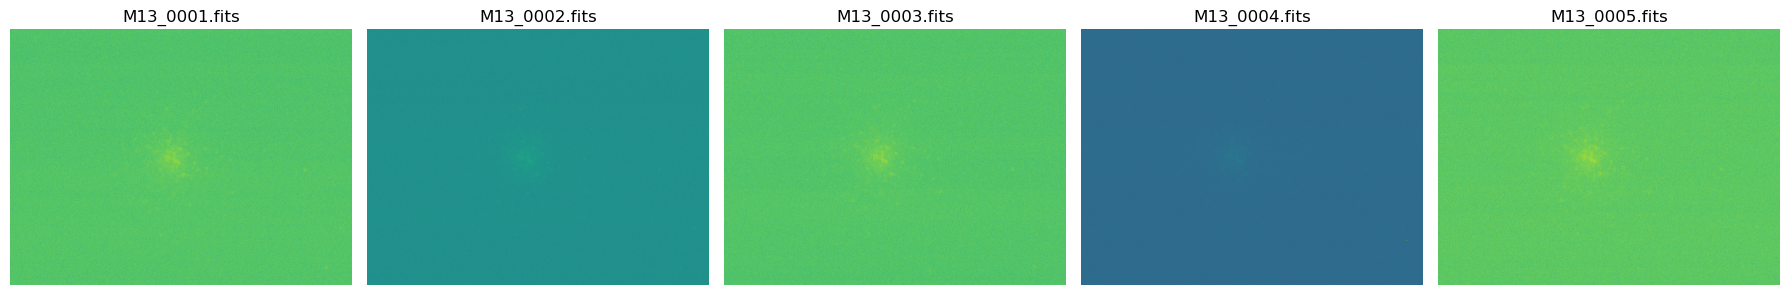

/var/folders/zr/svh_f4p54gg_mttfgnt4npvm0000gn/T/ipykernel_21141/3498872874.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


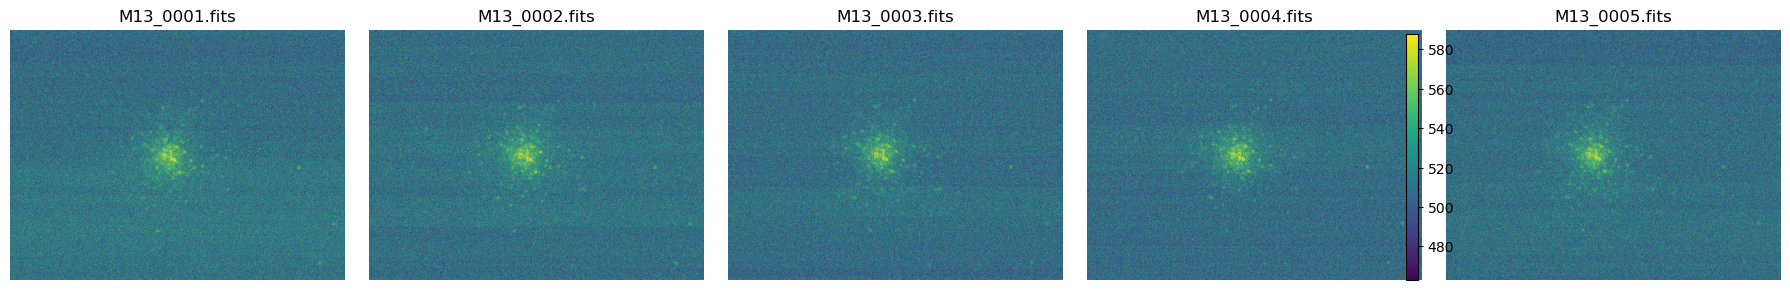

In [9]:
import matplotlib.pyplot as plt
import numpy as np

#3.2.1 
fig, axes = plt.subplots(1, len(images), figsize=(18, 4))
for ax, img, fn in zip(axes, images, files):
    im = ax.imshow(img, origin="lower")
    ax.set_title(os.path.basename(fn))
    ax.axis("off")
plt.tight_layout()
plt.show()

#3.2.2
all_pixels = np.hstack([img.ravel() for img in images])

vmin, vmax = np.percentile(all_pixels, 5), np.percentile(all_pixels, 99.5)

fig, axes = plt.subplots(1, len(images), figsize=(18, 4))
for ax, img, fn in zip(axes, images, files):
    im = ax.imshow(img, origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(os.path.basename(fn))
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()
# Something I noticed is that, each image stretches its own min/max so they can look “equally contrasted."

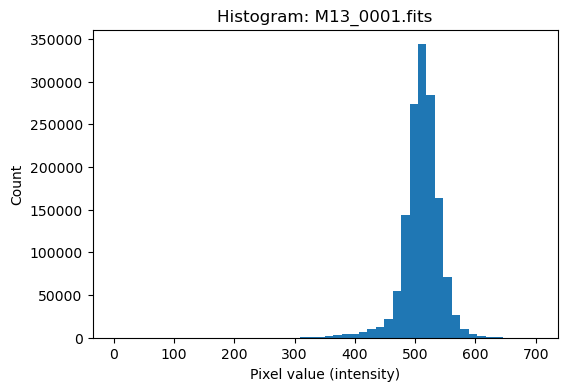

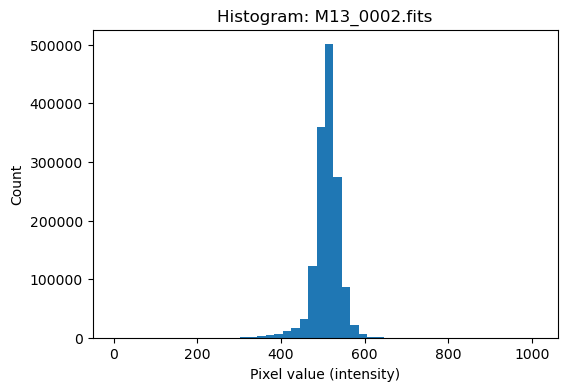

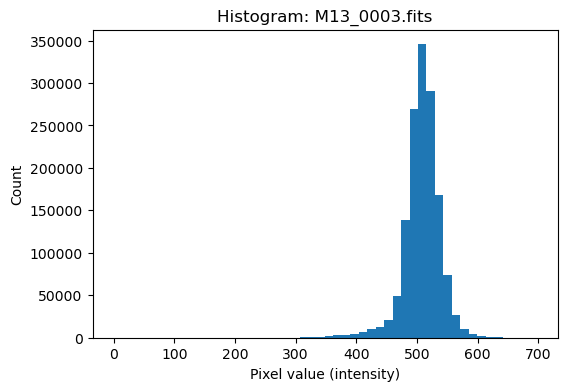

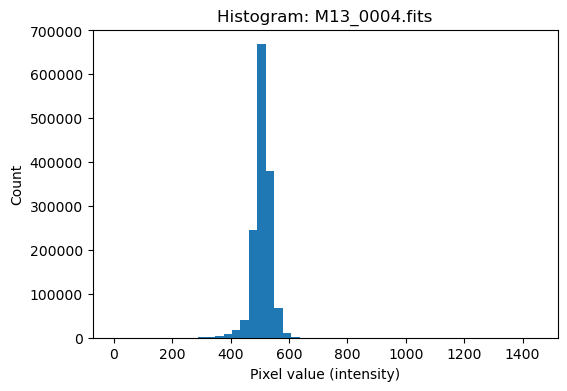

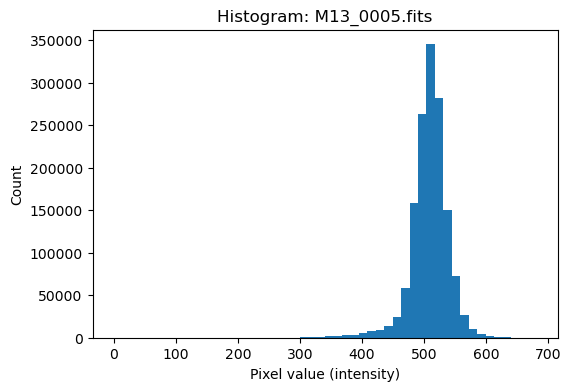

Mean pixel values:
M13_0001.fits = 510.4706668600796
M13_0002.fits = 509.7460150033157
M13_0003.fits = 508.0498729000884
M13_0004.fits = 507.90583554376656
M13_0005.fits = 508.7919920148099

Median pixel values:
M13_0001.fits = 512.0
M13_0002.fits = 511.0
M13_0003.fits = 510.0
M13_0004.fits = 509.0
M13_0005.fits = 510.0


In [10]:
import matplotlib.pyplot as plt
import numpy as np

means = []
medians = []

for img, fn in zip(images, files):
    data = img.ravel()

    plt.figure(figsize=(6,4))
    plt.hist(data, bins=50)
    plt.title(f"Histogram: {os.path.basename(fn)}")
    plt.xlabel("Pixel value (intensity)")
    plt.ylabel("Count")
    plt.show()

    means.append(np.mean(data))
    medians.append(np.median(data))

print("Mean pixel values:")
for fn, m in zip(files, means):
    print(os.path.basename(fn), "=", m)

print("\nMedian pixel values:")
for fn, m in zip(files, medians):
    print(os.path.basename(fn), "=", m)
# a) x-axis = pixel intensity, y-axis = how many pixels fall in that bin
# b) it means to split the pixel-value range into 50 intervals
# c) Most data is usually centered around the background/sky level
# d) The spread is like the width of the main bulk of the histogram
# e) I used the printed mean/median from the code

Median pixel intensity of combined image = 510.0


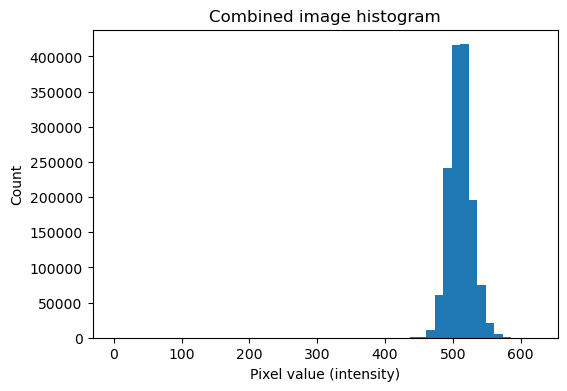

Chosen vmin=467.09, vmax=567.09, (vmax-vmin)=100.00


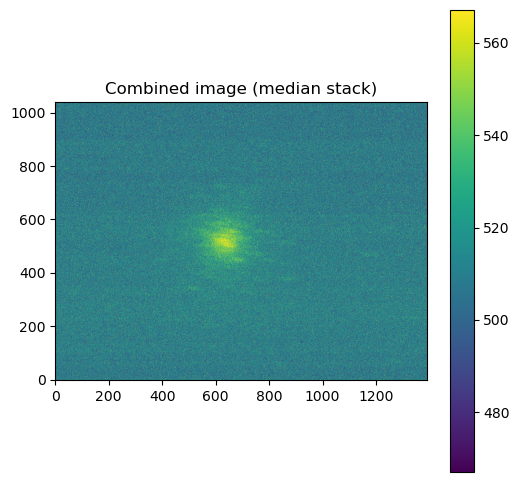

Saved combined.fits


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

stack = np.stack(images, axis=0)
combined_image = np.median(stack, axis=0)

new_median = np.median(combined_image)
print("Median pixel intensity of combined image =", new_median)

flat = combined_image.ravel()

plt.figure(figsize=(6,4))
counts, bin_edges, _ = plt.hist(flat, bins=50)
plt.title("Combined image histogram")
plt.xlabel("Pixel value (intensity)")
plt.ylabel("Count")
plt.show()

peak_idx = np.argmax(counts)
peak_center = 0.5 * (bin_edges[peak_idx] + bin_edges[peak_idx + 1])

vmin = peak_center - 50
vmax = peak_center + 50
print(f"Chosen vmin={vmin:.2f}, vmax={vmax:.2f}, (vmax-vmin)={vmax-vmin:.2f}")

plt.figure(figsize=(6,6))
plt.imshow(combined_image, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.title("Combined image (median stack)")
plt.show()

fits.writeto("combined.fits", combined_image, overwrite=True)
print("Saved combined.fits")
